In [1]:
#!pip3 install shap
#!ln -s /eos/user/c/caruta/.local/lib/python3.11/site-packages/shap shap
#!ln -s /eos/user/c/caruta/.local/lib/python3.11/site-packages/slicer slicer
#import shap

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
import shap
import numpy as np
import pandas as pd
from IPython.display import clear_output
import matplotlib.pyplot as plt
import tqdm
import uproot
from torch.utils.tensorboard import SummaryWriter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score
import seaborn as sn
from tqdm import tqdm
import ROOT

%matplotlib inline

print(torch.__version__)

2025-07-10 14:38:19.914081: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-10 14:38:19.979530: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Welcome to JupyROOT 6.30/04
2.1.0a0


In [3]:
def distance_corr(
        var_1:torch.tensor,
        var_2:torch.tensor,
        normedweight:torch.tensor,
        power=1,
        )->torch.tensor:
    """
    Compute the distance correlation function
    between two variables.

    Args:
        var_1 (torch.tensor): The first variable.
        var_2 (torch.tensor): The second variable.
        normedweight (torch.tensor): The weight matrix.
        power (int): The power of the distance correlation.

    Returns:
        torch.tensor: The distance correlation between the two variables.
    """
    
    # Normalize the weights
    normedweight = normedweight/torch.sum(normedweight)*len(var_1)
    
    xx = var_1.view(-1, 1).repeat(1, len(var_1)).view(len(var_1),len(var_1))
    yy = var_1.repeat(len(var_1),1).view(len(var_1),len(var_1))
    amat = (xx-yy).abs()

    xx = var_2.view(-1, 1).repeat(1, len(var_2)).view(len(var_2),len(var_2))
    yy = var_2.repeat(len(var_2),1).view(len(var_2),len(var_2))
    bmat = (xx-yy).abs()

    amatavg = torch.mean(amat*normedweight,dim=1)
    Amat=amat-amatavg.repeat(len(var_1),1).view(len(var_1),len(var_1))\
        -amatavg.view(-1, 1).repeat(1, len(var_1)).view(len(var_1),len(var_1))\
        +torch.mean(amatavg*normedweight)

    bmatavg = torch.mean(bmat*normedweight,dim=1)
    Bmat=bmat-bmatavg.repeat(len(var_2),1).view(len(var_2),len(var_2))\
        -bmatavg.view(-1, 1).repeat(1, len(var_2)).view(len(var_2),len(var_2))\
        +torch.mean(bmatavg*normedweight)

    ABavg = torch.mean(Amat*Bmat*normedweight,dim=1)
    AAavg = torch.mean(Amat*Amat*normedweight,dim=1)
    BBavg = torch.mean(Bmat*Bmat*normedweight,dim=1)

    if(power==1):
        dCorr=(torch.mean(ABavg*normedweight))/torch.sqrt((torch.mean(AAavg*normedweight)*torch.mean(BBavg*normedweight)))
    elif(power==2):
        dCorr=(torch.mean(ABavg*normedweight))**2/(torch.mean(AAavg*normedweight)*torch.mean(BBavg*normedweight))
    else:
        dCorr=((torch.mean(ABavg*normedweight))/torch.sqrt((torch.mean(AAavg*normedweight)*torch.mean(BBavg*normedweight))))**power
    
    return dCorr

In [4]:
class BCEWithDecorrelationLoss(nn.Module):
    def __init__(self, lambda_corr=1.0):
        super().__init__()
        self.bce = nn.BCELoss()
        self.lambda_corr = lambda_corr

    def forward(self, y_pred, y_true, feature):
        bce_loss = self.bce(y_pred, y_true)
        corr_loss = distance_corr(y_pred, feature, torch.ones(len(y_pred)).to(device))
        total_loss = bce_loss + self.lambda_corr * corr_loss
        return total_loss
    
    def getBCE(self, y_pred, y_true):
        with torch.no_grad():
            return self.bce(y_pred, y_true).detach().cpu()
        
    def getDisCo(self, y_pred, feature):
        with torch.no_grad():
            return distance_corr(y_pred, feature, torch.ones(len(y_pred)).to(device)).detach().cpu()

In [5]:
def get_arrays(tree, branch_list):
    _dict = {}
    for _br in branch_list:
        _dict[_br] = getattr(tree[_br].arrays(), _br)
    return pd.DataFrame.from_dict(_dict)

def get_input_features(df, train_list, cuts=''):
    if cuts=='': return df[train_list].to_numpy()
    _df = df[df.eval(cuts)]
    return _df[train_list].to_numpy()

In [6]:
## Normalization factors (5 to 25 GeV)
#x_sec_lowMass = [20.47, 13.19, 9.626, 5.655, 4.177, 3.255, 1.706, 0.6864, 0.3746, 0.2046] #m1,m2,m3,m4,m5,m10,m15,m20,m25 
#x_sec_lowMass = [13.19, 5.655, 4.177, 0.6864, 0.3746, 0.2046] #m2,m4,m5,m15,m20,m25 -- ORIGINAL!

xsec_pos = [1.307E+01, 5.711E+00, 4.209E+00, 8.467E-01, 4.606E-01, 2.503E-01, 1.360E-01] #m2,m4,m5,m15,m20,m25,m30
xsec_neg = [1.026E+01, 4.442E+00, 3.302E+00, 6.966E-01, 3.723E-01, 2.059E-01, 1.130E-01] #m2,m4,m5,m15,m20,m25,m30
x_sec_lowMass = [sum(x) for x in zip(xsec_pos, xsec_neg)]

k_fact = 1.3
lumi = 138000
norm_fact = []
for Zp_mass in x_sec_lowMass:
    norm_fact.append(Zp_mass*k_fact*lumi/(300000))
#print(norm_fact)

list_LowMass = [1,2,3,4,5,10,15,20,25,30]
#list_LowMass_reduced = [2,4,5,15,20,25,30]
list_LowMass_reduced = [1.3, 3.3, 7.5, 8.5, 11.5, 12.5]

In [7]:
training_variables = ['worstsip3d','worstIso','Ht', 'Mt', 'Vt', 'met', 'm3l_pT','pTL1', 'pTL2', 'pTL3',#'dPhiOS1','dPhiOS2', #'massZ1',
                      #'tightIdL1', 'tightIdL2', 'tightIdL3', 
                      'worstdxy', #'mvaIdL1', 'mvaIdL2', 'mvaIdL3',
                      #'softmvaL1', 'softmvaL2', 'softmvaL3', 
                      'mvaLowPtL1', 'mvaLowPtL2', 'mvaLowPtL3', #'massZ1',
                      #'worstdz', 'dRM1', 'dRM2', 'massZ0',
                      'ZpMass']
spectator_variables = ['massZ1', 'massZ2', 'Event', 'Run', 'ZpMass', 'pTL4', 'm4l', 'medIdL4', 'IsoL4', 'sip3dL4', 'm3l']
eval_variables = ['worstsip3d','worstIso','Ht', 'Mt', 'Vt', 'met', 'm3l_pT', 'pTL1', 'pTL2', 'pTL3',#'dPhiOS1','dPhiOS2', #'massZ1'
                  #'tightIdL1', 'tightIdL2', 'tightIdL3'
                  'worstdxy', #'mvaIdL1', 'mvaIdL2', 'mvaIdL3',
                  #'softmvaL1', 'softmvaL2', 'softmvaL3', 
                  'mvaLowPtL1', 'mvaLowPtL2', 'mvaLowPtL3', #'massZ1',
                  #'worstdz', 'dRM1', 'dRM2', 'massZ0'
                 ]

mass_var = ['massZ1']

In [8]:
## New ntuples
filename_sgn = 'NtupleSkimmed/Wto3l_M1-70_v3fourMore_June10_highMass_False_extension_True_noDiMuVeto.root'
filename_sgn_ext = 'NtupleSkimmed/Wto3l_M1-70_v3fourMore_June10_highMass_False_extension_True_noDiMuVeto_SRext.root' # with 20sigma SB
filename_bkg = 'NtupleSkimmed/Muon_Run2_noDuplicates_v3fourMore_June10_highMass_False_extension_True_noDiMuVeto.root'
path_bkgMC = 'NtupleSkimmed/FullRun_bkg_v3fourMore_Jan25_highMass_False_extension_True_noDiMuVeto/'

#filename_sgn = '/eos/user/c/caruta/SWAN_projects/analysis_xgboost_cloned/NewSkimmedTrees/NewTree_forDNN/Wto3l_5-80_FullRun2_v3_bis_looserPresel.root'
#filename_bkg = '/eos/user/c/caruta/SWAN_projects/analysis_xgboost_cloned/NewSkimmedTrees/NewTree_forDNN/Muon_FullRun2_noDuplicates_v3_bis_looserPresel.root'
#filename_sgn = '/eos/user/c/caruta/SWAN_projects/analysis_xgboost_cloned/NewSkimmedTrees/NewTree_forDNN/Wto3l_5-80_FullRun2_v3_bis_looserPresel.root'
#filename_bkg = '/eos/user/c/caruta/SWAN_projects/analysis_xgboost_cloned/NewSkimmedTrees/NewTree_forDNN/Muon_FullRun2_noDuplicates_v3_bis_looserPresel.root'

In [9]:
# load data 
input_file_sgn = uproot.open(filename_sgn)
input_tree_sgn = get_arrays(input_file_sgn['passedEvents'], training_variables+spectator_variables)
input_file_bkg = uproot.open(filename_bkg)
input_tree_bkg = get_arrays(input_file_bkg['passedEvents'], training_variables+spectator_variables)

# prepare bkg and signal samples for training
vetoes = '(massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & pTL4==0 &'

preSel_bkg = vetoes + 'ZpMass>0 & ZpMass<=30 & ZpMass!=1 & ZpMass!=3 & ZpMass!=10'#0
preSel_sgn = vetoes + 'ZpMass>0 & ZpMass<=30 & ZpMass!=1 & ZpMass!=3 & ZpMass!=10'#0

bkg_trainX = get_input_features(input_tree_bkg, training_variables, preSel_bkg)
sig_trainX = get_input_features(input_tree_sgn, training_variables, preSel_sgn)
massBkg_trainX = get_input_features(input_tree_bkg, mass_var, preSel_bkg)
massSig_trainX = get_input_features(input_tree_sgn, mass_var, preSel_sgn)
print("bkg evts: ", len(bkg_trainX))
print("sig evts: ", len(sig_trainX))

bkg evts:  57915
sig evts:  227320


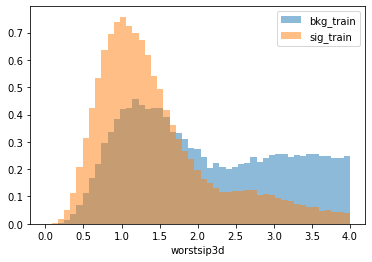

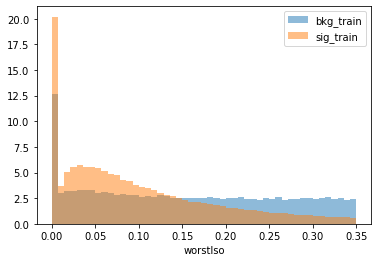

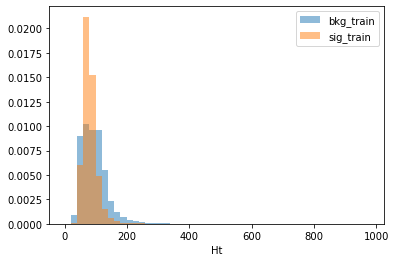

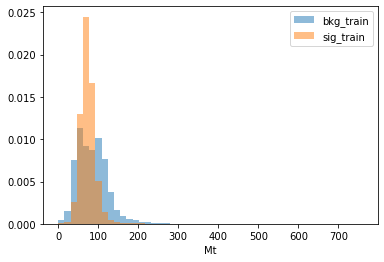

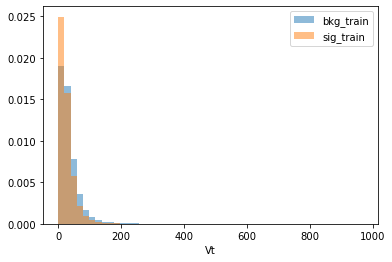

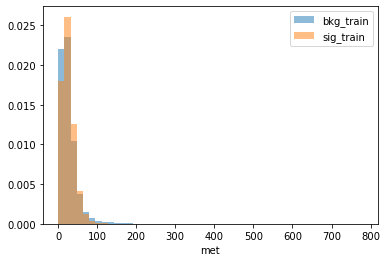

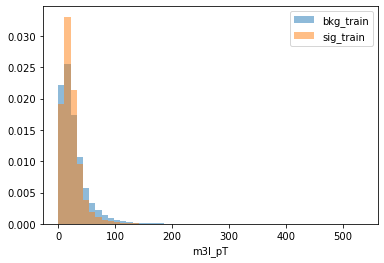

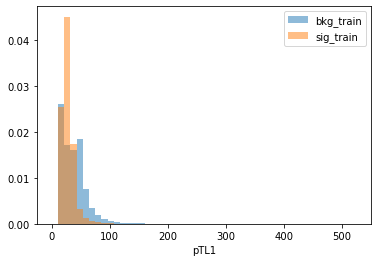

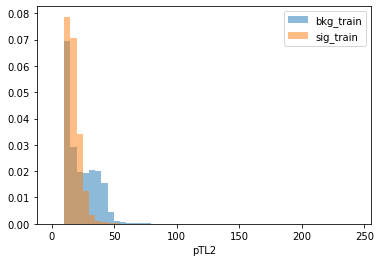

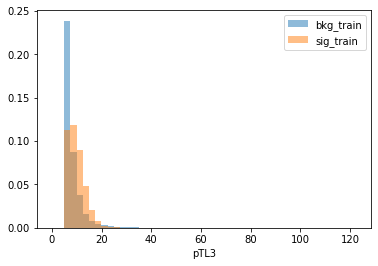

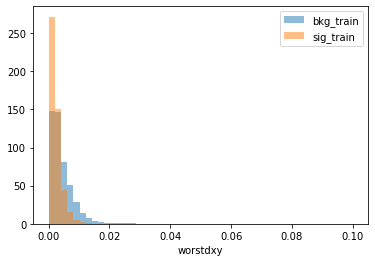

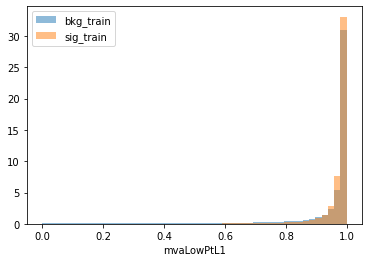

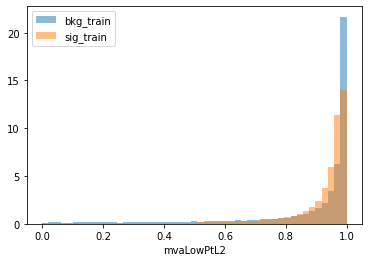

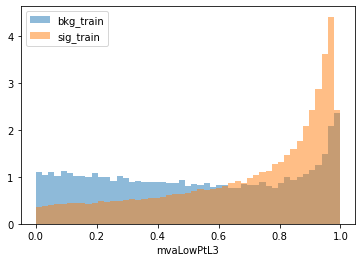

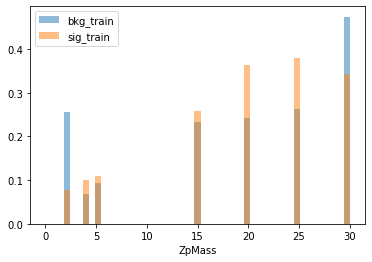

In [10]:
## Plotting input variables
#print(sig_trainX[:,0]) 
#print(len(sig_trainX[:,0]))

it = 0
for inputVar in (training_variables):
    maxN = np.max(bkg_trainX[:,it])
    if (inputVar == 'worstdz' or inputVar == 'worstdxy'):
        plt.hist(bkg_trainX[:,it], label='bkg_train', density=True, alpha=0.5, bins=np.linspace(0, 0.1, 50))
        plt.hist(sig_trainX[:,it], label='sig_train', density=True, alpha=0.5, bins=np.linspace(0, 0.1, 50))
    else:
        plt.hist(bkg_trainX[:,it], label='bkg_train', density=True, alpha=0.5, bins=np.linspace(0, maxN, 50))
        plt.hist(sig_trainX[:,it], label='sig_train', density=True, alpha=0.5, bins=np.linspace(0, maxN, 50))
    
    plt.xlabel(inputVar)
    #plt.yscale("log")
    plt.legend()
    plt.show()
    it+=1

In [11]:
#label signal and bkg & weight properly each mass point
bkg_trainY = np.zeros(len(bkg_trainX))
sig_trainY = np.ones(len(sig_trainX))
weights_bkg_trainY = np.zeros(len(bkg_trainX))
weights_sig_trainY = np.zeros(len(sig_trainX))
#weights_bkg_trainY = np.array([1./len(bkg_trainY)]*len(bkg_trainY))
#weights_sig_trainY = np.array([1./len(sig_trainY)]*len(sig_trainY))

n = 0
ZpMass_weight_bkg = np.zeros(len(list_LowMass_reduced)) # weights for different ZpMass values
ZpMass_weight_sig = np.zeros(len(list_LowMass_reduced)) # weights for different ZpMass values
for it in list_LowMass_reduced:
    evts_bkg = np.count_nonzero((bkg_trainX[:,(len(training_variables)-1)]) == it)
    evts_sig = np.count_nonzero((sig_trainX[:,(len(training_variables)-1)]) == it)
    ZpMass_weight_bkg[n] = 1./evts_bkg*len(list_LowMass_reduced)
    ZpMass_weight_sig[n] = 1./evts_sig*len(list_LowMass_reduced)
    n +=1

weights_bkg_trainY = np.zeros(len(bkg_trainY))
weights_sig_trainY = np.zeros(len(sig_trainY))
for i in range(len(bkg_trainY)):
    index = list_LowMass_reduced.index(bkg_trainX[i,(len(training_variables)-1)])
    weights_bkg_trainY[i] = ZpMass_weight_bkg[index]      
for i in range(len(sig_trainY)):
    index = list_LowMass_reduced.index(sig_trainX[i,(len(training_variables)-1)])
    weights_sig_trainY[i] = ZpMass_weight_sig[index]  

# split data into X and y
X = np.concatenate((bkg_trainX, sig_trainX))
Y = np.concatenate((bkg_trainY, sig_trainY))
W = np.concatenate((weights_bkg_trainY, weights_sig_trainY))

Mass = np.concatenate((massBkg_trainX, massSig_trainX))

mass:  2
mass:  4
mass:  5
mass:  15
mass:  20
mass:  25
mass:  30


In [12]:
X_train, X_test = train_test_split(X, test_size=0.5, random_state=23)
Y_train, Y_test = train_test_split(Y, test_size=0.5, random_state=23)
W_train, W_test = train_test_split(W, test_size=0.5, random_state=23)
#print(X_train)

Mass_train, Mass_test = train_test_split(Mass, test_size=0.5, random_state=23)

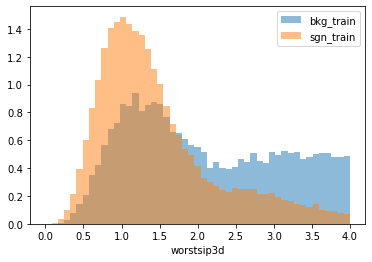

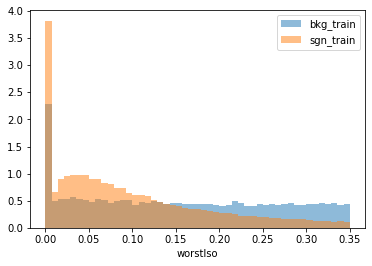

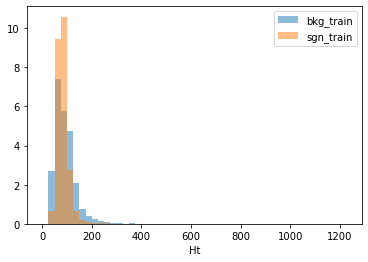

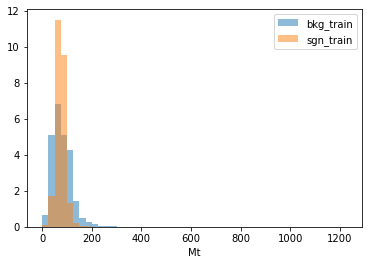

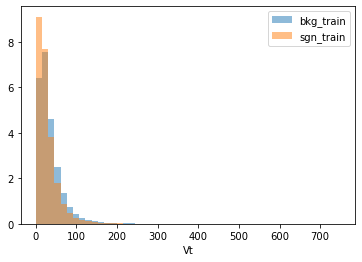

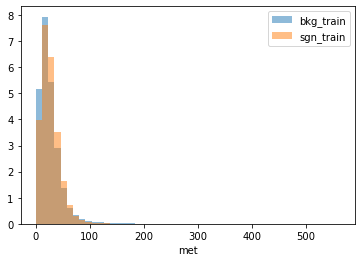

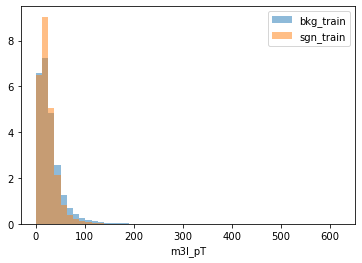

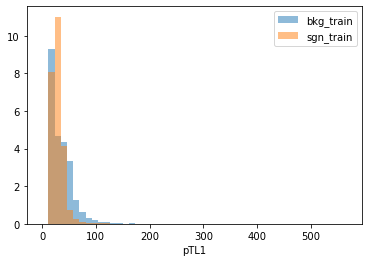

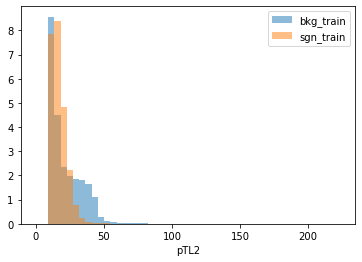

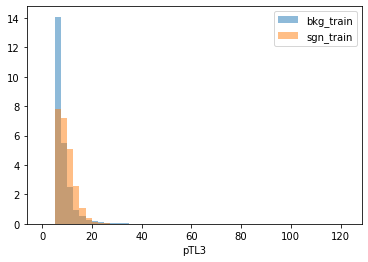

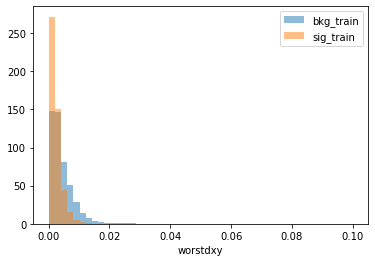

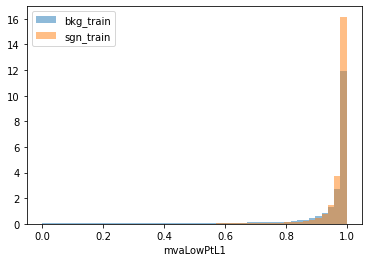

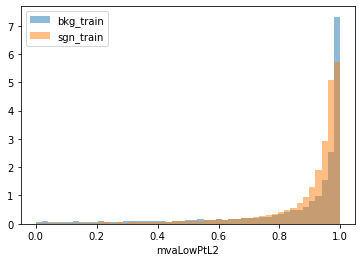

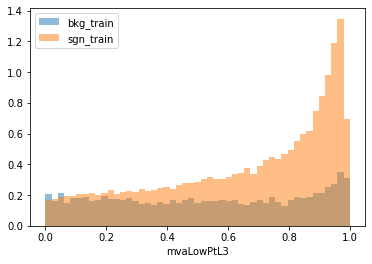

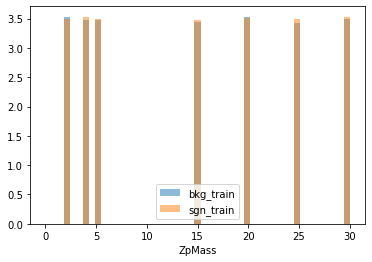

In [13]:
it = 0
for inputVar in (training_variables):
    maxN_train = np.max(X_train[:,it])
    #maxN_test = np.max(X_test[:,it])
    if (inputVar == 'worstdz' or inputVar == 'worstdxy'):
        plt.hist(bkg_trainX[:,it], label='bkg_train', density=True, alpha=0.5, bins=np.linspace(0, 0.1, 50))
        plt.hist(sig_trainX[:,it], label='sig_train', density=True, alpha=0.5, bins=np.linspace(0, 0.1, 50))
    else:
        plt.hist((X_train[:, it])[Y_train == 0], label='bkg_train', density=False, weights=(W_train[Y_train == 0]), alpha=0.5, bins=np.linspace(0, maxN_train, 50))
        plt.hist((X_train[:, it])[Y_train == 1], label='sgn_train', density=False, weights=(W_train[Y_train == 1]), alpha=0.5, bins=np.linspace(0, maxN_train, 50))
        #plt.hist((X_test[:, it])[Y_test == 0], label='bkg_test', density=False, weights=(W_test[Y_test == 0]), alpha=0.3, bins=np.linspace(0, maxN_test, 50))
        #plt.hist((X_test[:, it])[Y_test == 1], label='sgn_test', density=False, weights=(W_test[Y_test == 1]), alpha=0.3, bins=np.linspace(0, maxN_test, 50))
    plt.xlabel(inputVar)
    plt.legend()
    plt.show()
    it+=1

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train, sample_weight=W_train)
X_test = scaler.transform(X_test)

In [15]:
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32).reshape(-1,1)
Mass_train = torch.tensor(Mass_train, dtype=torch.float32)
Mass_test = torch.tensor(Mass_test, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32).reshape(-1,1)

In [16]:
sampler = torch.utils.data.WeightedRandomSampler(W_train, len(W_train), replacement=True)

In [17]:
class DataSet(torch.utils.data.Dataset):
    '''
    Class to define the dataset for the DataLoader.
    '''
    def __init__(self, data, labels, mass):
        self.data = data
        #self.constraint_obs = constraint_obs
        self.labels = labels
        self.mass = mass
        #self.xs_weights = xs_weights
        #self.weights = weights # Needed to calculate closure correctly

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        #return self.data[index], self.constraint_obs[index], self.labels[index], self.xs_weights[index], self.weights[index]
        return self.data[index], self.labels[index], self.mass[index]

In [18]:
loader = torch.utils.data.DataLoader(DataSet(X_train, Y_train, Mass_train), batch_size=4096, sampler=sampler)

In [19]:
# Fully connected NN with 3 layers
##The model expects rows of data with 7 variables (the first argument at the first layer set to 7)
##The first hidden layer has 12 neurons, followed by a ReLU activation function
##The second hidden layer has 7 neurons, followed by another ReLU activation function
##The output layer has one neuron, followed by a sigmoid activation function

if torch.cuda.is_available():         
    device = torch.device('cuda')
    print("Cuda available")
else:
    device = torch.device('cpu')
    print("Cuda NOT available, using cpu")


model = nn.Sequential(
    nn.Linear(len(training_variables), 2*len(training_variables)), ##11->15, 15, 20
    nn.ReLU(),
    nn.Linear(2*len(training_variables), len(training_variables)),
    nn.ReLU(),
    nn.Linear(len(training_variables), 1),
    nn.Sigmoid()
).to(device)
    
print(model)

#class MyClassifier(nn.Module):
#    def __init__(self):
#        super().__init__()
#        self.hidden1 = nn.Linear(8, 12)
#        self.act1 = nn.ReLU()
#        self.hidden2 = nn.Linear(12, 8)
#        self.act2 = nn.ReLU()
#        self.output = nn.Linear(8, 1)
#        self.act_output = nn.Sigmoid()
 
#    def forward(self, x):
#        x = self.act1(self.hidden1(x))
#        x = self.act2(self.hidden2(x))
#        x = self.act_output(self.output(x))
#        return x
 
#model = MyClassifier()
#print(model)

Cuda available
Sequential(
  (0): Linear(in_features=15, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=15, bias=True)
  (3): ReLU()
  (4): Linear(in_features=15, out_features=1, bias=True)
  (5): Sigmoid()
)


In [20]:
#loss_fn = nn.BCELoss()  # binary cross entropy
loss_fn = BCEWithDecorrelationLoss(lambda_corr=36)
optimizer = optim.Adam(model.parameters(), lr=0.001)

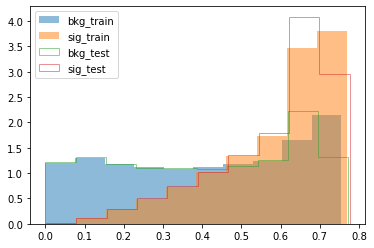

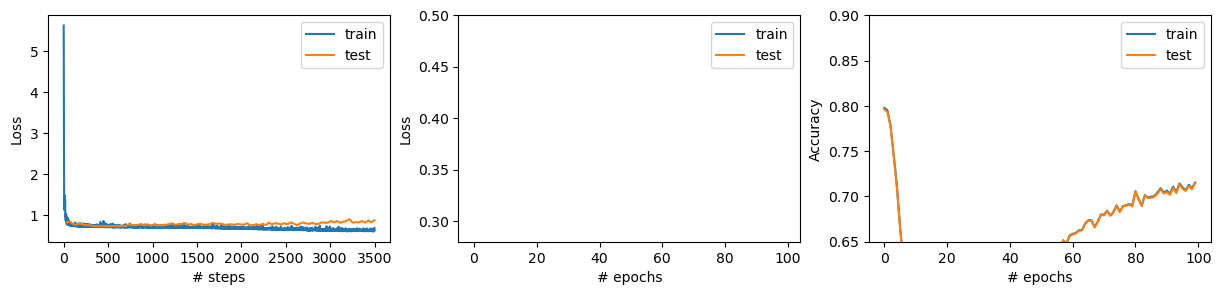

In [21]:
### Training
n_epochs = 100 # Epoch: Passes the entire training dataset to the model once
batch_size = 4096 # Batch: One or more samples passed to the model, from which the gradient descent algorithm will be executed for one iteration
model.train()

# some quantities to plot
train_losses = []
test_losses = []
train_BCE = []
train_DisCo = []
train_losses_perEpoch = []
y_pred_perEpoch = []
accuracy_train = []
accuracy_test = []

for epoch in range(n_epochs):
    for x,y,m in tqdm(loader, desc=f"Training epoch {epoch}", leave=False):
        y_pred = model(x.to(device))
        #loss = loss_fn(y_pred, y.to(device))
        loss = loss_fn(y_pred, y.to(device), m.to(device))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        # remember the loss value at this step
        train_losses.append(loss.detach().item())
        train_BCE.append(loss_fn.getBCE(y_pred, y.to(device)))
        train_DisCo.append(loss_fn.getDisCo(y_pred, m.to(device)))
    #print(f'Finished epoch {epoch}, latest loss {loss.detach():.2f}')
    
    # evaluate test loss and metrics
    with torch.no_grad(): 
        y_pred_test = model(X_test.to(device))
        y_pred_train = model(X_train.to(device)) 
        test_losses.append( (loss_fn(y_pred_test[:2048], Y_test[:2048].to(device), Mass_test[:2048].to(device))).cpu())
        train_losses_perEpoch.append(loss.item())
        accuracy_train.append( (y_pred_train.round() == Y_train.to(device)).cpu().float().mean() )#
        accuracy_test.append( (y_pred_test.round() == Y_test.to(device)).cpu().float().mean() )#
    #print(f'Finished epoch {epoch}, latest loss {loss.detach():.2f}, accuracy {accuracy_test[-1]:.2f}')
 
plt.hist(y_pred_train[Y_train == 0].cpu(), label='bkg_train', density=True, alpha=0.5)
plt.hist(y_pred_train[Y_train == 1].cpu(), label='sig_train', density=True, alpha=0.5)
plt.hist(y_pred_test[Y_test == 0].cpu(), label='bkg_test', histtype='step', density=True, alpha=0.5)
plt.hist(y_pred_test[Y_test == 1].cpu(), label='sig_test', histtype='step', density=True, alpha=0.5)
plt.legend()

# Plotting performance
clear_output(wait=True)
plt.figure(figsize=(15, 3), dpi=100)
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='train')
plt.plot(
  np.linspace(0, len(train_losses), len(test_losses) + 1)[1:],
  test_losses, label='test'
)
plt.ylabel("Loss")
plt.xlabel("# steps")
plt.legend()
    
plt.subplot(1, 3, 2)
plt.plot(train_losses_perEpoch, label='train')
plt.plot(test_losses, label='test')
plt.ylabel("Loss")
plt.xlabel("# epochs")
plt.ylim(0.28, 0.5)
plt.legend()
        
plt.subplot(1, 3, 3)
plt.plot(accuracy_train, label='train')
plt.plot(accuracy_test, label='test')
plt.ylabel("Accuracy")
plt.xlabel("# epochs")
plt.ylim(0.65, 0.9)
plt.legend()
plt.show()

In [22]:
## SHAP dependence plots
#shap.plots.scatter(explainer.shap_values(data_sampled))


 Mass point:  2  | iteration n. 1
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  15181
bkg shape:  (261023, 14)
sgn shape:  (15181, 14)
X_eval_new:  276204
Y_eval_new:  276204
X_eval_new transformed:  276204
Y_pred_new:  276204
261023
15181


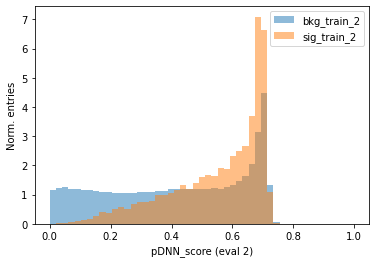

Going to save root file bkg
Going to save root file sgn
Done for mass  2

 Mass point:  4  | iteration n. 2
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  20079
bkg shape:  (261023, 14)
sgn shape:  (20079, 14)
X_eval_new:  281102
Y_eval_new:  281102
X_eval_new transformed:  281102
Y_pred_new:  281102
261023
20079


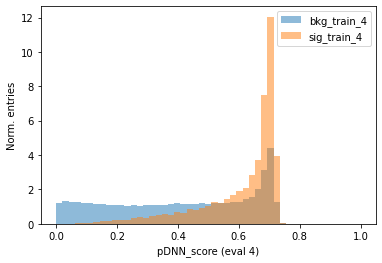

Going to save root file bkg
Going to save root file sgn
Done for mass  4

 Mass point:  5  | iteration n. 3
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  21961
bkg shape:  (261023, 14)
sgn shape:  (21961, 14)
X_eval_new:  282984
Y_eval_new:  282984
X_eval_new transformed:  282984
Y_pred_new:  282984
261023
21961


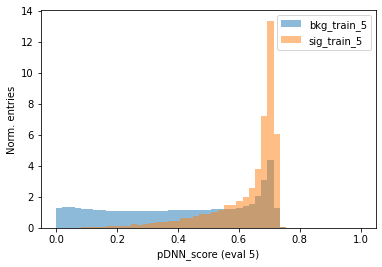

Going to save root file bkg
Going to save root file sgn
Done for mass  5

 Mass point:  15  | iteration n. 4
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  51430
bkg shape:  (261023, 14)
sgn shape:  (51430, 14)
X_eval_new:  312453
Y_eval_new:  312453
X_eval_new transformed:  312453
Y_pred_new:  312453
261023
51430


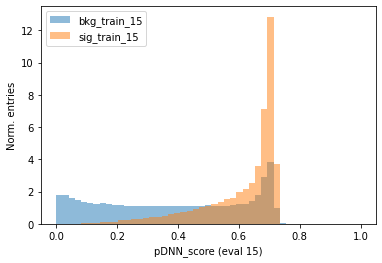

Going to save root file bkg
Going to save root file sgn
Done for mass  15

 Mass point:  20  | iteration n. 5
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  75866
bkg shape:  (261023, 14)
sgn shape:  (75866, 14)
X_eval_new:  336889
Y_eval_new:  336889
X_eval_new transformed:  336889
Y_pred_new:  336889
261023
75866


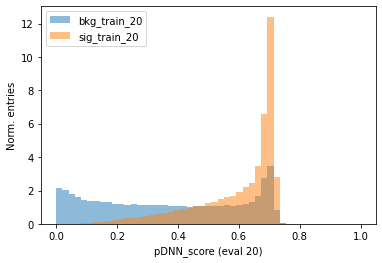

Going to save root file bkg
Going to save root file sgn
Done for mass  20

 Mass point:  25  | iteration n. 6
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  86400
bkg shape:  (261023, 14)
sgn shape:  (86400, 14)
X_eval_new:  347423
Y_eval_new:  347423
X_eval_new transformed:  347423
Y_pred_new:  347423
261023
86400


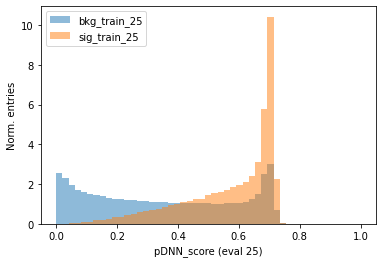

Going to save root file bkg
Going to save root file sgn
Done for mass  25

 Mass point:  30  | iteration n. 7
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  85990
bkg shape:  (261023, 14)
sgn shape:  (85990, 14)
X_eval_new:  347013
Y_eval_new:  347013
X_eval_new transformed:  347013
Y_pred_new:  347013
261023
85990


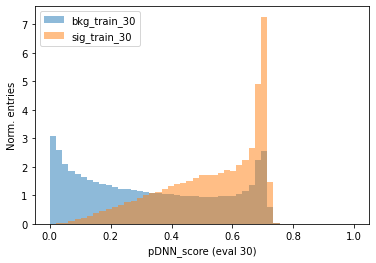

Going to save root file bkg
Going to save root file sgn
Done for mass  30


In [23]:
## Save tree with pDNN score (signal and data sidebands)

n_it = 1
bkg_evalY = []
sig_evalY = []
bkg_evalX = []
sgn_evalX = []
#list_LowMass_reduced = [2,4,5,15,20,25]

for n in list_LowMass_reduced:
    
    input_file_sgn = uproot.open(filename_sgn_ext)
    input_tree_sgn = get_arrays(input_file_sgn['passedEvents'], training_variables+spectator_variables)
    input_file_bkg = uproot.open(filename_bkg)
    input_tree_bkg = get_arrays(input_file_bkg['passedEvents'], training_variables+spectator_variables)
    
    phiVeto = '(massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045)'
    JPsiVeto = '(massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25)'
    PsiPrimeVeto = '(massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75)'
    UpsilonVeto = '(massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0)'
    veto_diMuReso = phiVeto +' & '+ JPsiVeto +' & '+ PsiPrimeVeto +' & '+ UpsilonVeto +' & ' 
    
    print("\n Mass point: ", n, " | iteration n.", n_it)
    #pre_sel_bkg_eval = veto_diMuReso + '(massZ2>'+str(n-(n*0.2))+' & massZ2<'+str(n-(n*0.02))+') | (massZ2>'+str(n+(n*0.02))+' & massZ2<'+str(n+(n*0.2))+')'
    pre_sel_bkg_eval = 'massZ2>0' #placeholder
    print("pre_sel_bkg_eval: ", pre_sel_bkg_eval)
    preSel_bkg_eval = pre_sel_bkg_eval #'(massZ1>48. & massZ1<58.8) | (massZ1>61.2 & massZ1<72.)' #'ZpMass>-1'
    #preSel_sgn_eval = veto_diMuReso+'ZpMass=='+str(n) #ZpMass==60' # 'ZpMass==55 | ZpMass==65'
    preSel_sgn_eval ='ZpMass=='+str(n)

    bkg_evalX = get_input_features(input_tree_bkg, eval_variables, preSel_bkg_eval)
    sgn_evalX = get_input_features(input_tree_sgn, eval_variables, preSel_sgn_eval)
    bkg_evalY = np.zeros(len(bkg_evalX))
    sig_evalY = np.ones(len(sgn_evalX))
    print("bkg eval evts: ", len(bkg_evalX))
    print("sgn eval evts: ", len(sgn_evalX))
    print("bkg shape: ", bkg_evalX.shape)
    print("sgn shape: ", sgn_evalX.shape)
    
    test_bkg = np.full((len(bkg_evalX), 1), n)
    bkg_evalX = np.append(bkg_evalX,test_bkg,1)
    test_sgn = np.full((len(sgn_evalX), 1), n)
    sgn_evalX = np.append(sgn_evalX,test_sgn,1)
    #print(sgn_evalX)
    #print(bkg_evalX)
    
    X_eval_new = np.concatenate((bkg_evalX, sgn_evalX))
    Y_eval_new = np.concatenate((bkg_evalY, sig_evalY))
    print("X_eval_new: ", len(X_eval_new))
    print("Y_eval_new: ", len(X_eval_new))
    
    X_eval_new = scaler.transform(X_eval_new)
    Y_pred_new = model(torch.tensor(X_eval_new, dtype=torch.float32).to(device))
    print("X_eval_new transformed: ", len(X_eval_new))
    print("Y_pred_new: ", len(Y_pred_new))

    print(len(Y_pred_new[Y_eval_new == 0]))
    print(len(Y_pred_new[Y_eval_new == 1]))
    
    input_tree_bkg = input_tree_bkg[input_tree_bkg.eval(preSel_bkg_eval)]
    input_tree_sgn = input_tree_sgn[input_tree_sgn.eval(preSel_sgn_eval)]
    input_tree_bkg['DNN_score'] = (Y_pred_new[Y_eval_new == 0].cpu()).detach().numpy()
    input_tree_sgn['DNN_score'] = (Y_pred_new[Y_eval_new == 1].cpu()).detach().numpy()
    
    plt.hist(Y_pred_new[Y_eval_new == 0].detach().cpu().numpy(), label='bkg_train_'+str(n), density=True, alpha=0.5, bins=np.linspace(0, 1, 50))
    plt.hist(Y_pred_new[Y_eval_new == 1].detach().cpu().numpy(), label='sig_train_'+str(n), density=True, alpha=0.5, bins=np.linspace(0, 1, 50))
    plt.xlabel('pDNN_score (eval '+str(n)+')')
    plt.ylabel('Norm. entries')
    plt.legend()
    plt.show()

    ### Saving trees
    input_tree_bkg.to_csv("MiniTrees/MiniTree_bkg_pDNN_"+str(n)+".csv")
    input_tree_bkg_RDF = ROOT.RDF.FromCSV("MiniTrees/MiniTree_bkg_pDNN_"+str(n)+".csv", True, ',', 1000)
    print("Going to save root file bkg")
    input_tree_bkg_RDF.Snapshot("passedEvents", "MiniTrees/MiniTree_bkg_pDNN_"+str(n)+".root")

    input_tree_sgn.to_csv("MiniTrees/MiniTree_sgn_pDNN_"+str(n)+".csv")
    input_tree_sgn_RDF = ROOT.RDF.FromCSV("MiniTrees/MiniTree_sgn_pDNN_"+str(n)+".csv", True, ',', 1000)
    print("Going to save root file sgn")
    input_tree_sgn_RDF.Snapshot("passedEvents", "MiniTrees/MiniTree_sgn_pDNN_"+str(n)+".root")

    print("Done for mass ", n)
    n_it += 1
    

In [24]:
## Save model
# Save the state dictionary
torch.save(model.state_dict(), "pdnn_model_highMass_Apr18_DisCo_lambda38.pth")


 Mass point:  2  | iteration n. 1
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  15181
bkg shape:  (261023, 14)
sgn shape:  (15181, 14)
X_eval_new:  276204
Y_eval_new:  276204
X_eval_new transformed:  276204
Y_pred_new:  276204
261023
15181


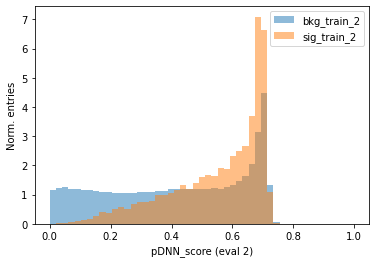

Going to save root file bkg
Going to save root file sgn
Done for mass  2

 Mass point:  4  | iteration n. 2
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  20079
bkg shape:  (261023, 14)
sgn shape:  (20079, 14)
X_eval_new:  281102
Y_eval_new:  281102
X_eval_new transformed:  281102
Y_pred_new:  281102
261023
20079


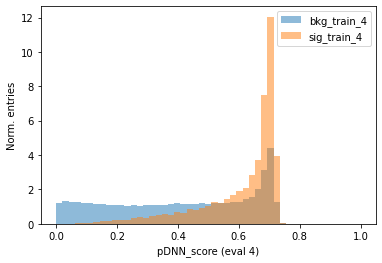

Going to save root file bkg
Going to save root file sgn
Done for mass  4

 Mass point:  5  | iteration n. 3
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  21961
bkg shape:  (261023, 14)
sgn shape:  (21961, 14)
X_eval_new:  282984
Y_eval_new:  282984
X_eval_new transformed:  282984
Y_pred_new:  282984
261023
21961


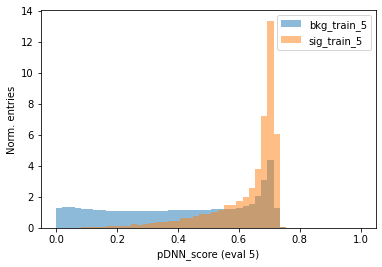

Going to save root file bkg
Going to save root file sgn
Done for mass  5

 Mass point:  15  | iteration n. 4
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  51430
bkg shape:  (261023, 14)
sgn shape:  (51430, 14)
X_eval_new:  312453
Y_eval_new:  312453
X_eval_new transformed:  312453
Y_pred_new:  312453
261023
51430


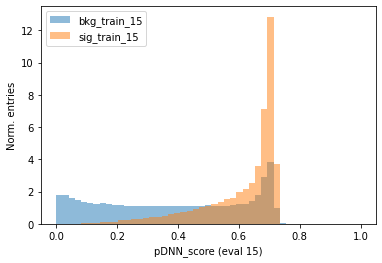

Going to save root file bkg
Going to save root file sgn
Done for mass  15

 Mass point:  20  | iteration n. 5
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  75866
bkg shape:  (261023, 14)
sgn shape:  (75866, 14)
X_eval_new:  336889
Y_eval_new:  336889
X_eval_new transformed:  336889
Y_pred_new:  336889
261023
75866


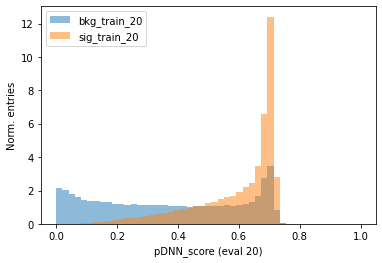

Going to save root file bkg
Going to save root file sgn
Done for mass  20

 Mass point:  25  | iteration n. 6
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  86400
bkg shape:  (261023, 14)
sgn shape:  (86400, 14)
X_eval_new:  347423
Y_eval_new:  347423
X_eval_new transformed:  347423
Y_pred_new:  347423
261023
86400


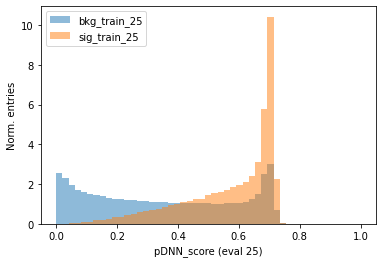

Going to save root file bkg
Going to save root file sgn
Done for mass  25

 Mass point:  30  | iteration n. 7
pre_sel_bkg_eval:  massZ2>0
bkg eval evts:  261023
sgn eval evts:  85990
bkg shape:  (261023, 14)
sgn shape:  (85990, 14)
X_eval_new:  347013
Y_eval_new:  347013
X_eval_new transformed:  347013
Y_pred_new:  347013
261023
85990


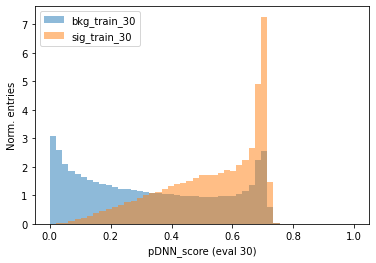

Going to save root file bkg
Going to save root file sgn
Done for mass  30


In [25]:
## Save tree with pDNN score (signal and data sidebands)

n_it = 1
bkg_evalY = []
sig_evalY = []
bkg_evalX = []
sgn_evalX = []
list_LowMass_reduced = [2,4,5,15,20,25,30]
bkg_fact = [0.119, 0.11, 0.106, 0.111, 0.116, 0.108, 0.108]

for n in list_LowMass_reduced:
    
    input_file_sgn = uproot.open(filename_sgn_ext)
    input_tree_sgn = get_arrays(input_file_sgn['passedEvents'], training_variables+spectator_variables)
    input_file_bkg = uproot.open(filename_bkg)
    input_tree_bkg = get_arrays(input_file_bkg['passedEvents'], training_variables+spectator_variables)
    
    phiVeto = '(massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045)'
    JPsiVeto = '(massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25)'
    PsiPrimeVeto = '(massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75)'
    UpsilonVeto = '(massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0)'
    veto_diMuReso = phiVeto +' & '+ JPsiVeto +' & '+ PsiPrimeVeto +' & '+ UpsilonVeto +' & ' 
    
    print("\n Mass point: ", n, " | iteration n.", n_it)
    #pre_sel_bkg_eval = veto_diMuReso + '(massZ2>'+str(n-(n*0.2))+' & massZ2<'+str(n-(n*0.02))+') | (massZ2>'+str(n+(n*0.02))+' & massZ2<'+str(n+(n*0.2))+')'
    pre_sel_bkg_eval = 'massZ2>0' #placeholder
    print("pre_sel_bkg_eval: ", pre_sel_bkg_eval)
    preSel_bkg_eval = pre_sel_bkg_eval #'(massZ1>48. & massZ1<58.8) | (massZ1>61.2 & massZ1<72.)' #'ZpMass>-1'
    #preSel_sgn_eval = veto_diMuReso+'ZpMass=='+str(n) #ZpMass==60' # 'ZpMass==55 | ZpMass==65'
    preSel_sgn_eval ='ZpMass=='+str(n)

    bkg_evalX = get_input_features(input_tree_bkg, eval_variables, preSel_bkg_eval)
    sgn_evalX = get_input_features(input_tree_sgn, eval_variables, preSel_sgn_eval)
    bkg_evalY = np.zeros(len(bkg_evalX))
    sig_evalY = np.ones(len(sgn_evalX))
    print("bkg eval evts: ", len(bkg_evalX))
    print("sgn eval evts: ", len(sgn_evalX))
    print("bkg shape: ", bkg_evalX.shape)
    print("sgn shape: ", sgn_evalX.shape)
    
    test_bkg = np.full((len(bkg_evalX), 1), n)
    bkg_evalX = np.append(bkg_evalX,test_bkg,1)
    test_sgn = np.full((len(sgn_evalX), 1), n)
    sgn_evalX = np.append(sgn_evalX,test_sgn,1)
    
    X_eval_new = np.concatenate((bkg_evalX, sgn_evalX))
    Y_eval_new = np.concatenate((bkg_evalY, sig_evalY))
    print("X_eval_new: ", len(X_eval_new))
    print("Y_eval_new: ", len(X_eval_new))
    
    X_eval_new = scaler.transform(X_eval_new)
    Y_pred_new = model(torch.tensor(X_eval_new, dtype=torch.float32).to(device))
    print("X_eval_new transformed: ", len(X_eval_new))
    print("Y_pred_new: ", len(Y_pred_new))

    print(len(Y_pred_new[Y_eval_new == 0]))
    print(len(Y_pred_new[Y_eval_new == 1]))
    
    input_tree_bkg = input_tree_bkg[input_tree_bkg.eval(preSel_bkg_eval)]
    input_tree_sgn = input_tree_sgn[input_tree_sgn.eval(preSel_sgn_eval)]
    input_tree_bkg['DNN_score'] = (Y_pred_new[Y_eval_new == 0].cpu()).detach().numpy()
    input_tree_sgn['DNN_score'] = (Y_pred_new[Y_eval_new == 1].cpu()).detach().numpy()
    
    plt.hist(Y_pred_new[Y_eval_new == 0].detach().cpu().numpy(), label='bkg_train_'+str(n), density=True, alpha=0.5, bins=np.linspace(0, 1, 50))
    plt.hist(Y_pred_new[Y_eval_new == 1].detach().cpu().numpy(), label='sig_train_'+str(n), density=True, alpha=0.5, bins=np.linspace(0, 1, 50))
    plt.xlabel('pDNN_score (eval '+str(n)+')')
    plt.ylabel('Norm. entries')
    plt.legend()
    plt.show()

    ### Saving trees
    input_tree_bkg.to_csv("MiniTrees/MiniTree_bkg_pDNN_"+str(n)+".csv")
    input_tree_bkg_RDF = ROOT.RDF.FromCSV("MiniTrees/MiniTree_bkg_pDNN_"+str(n)+".csv", True, ',', 1000)
    print("Going to save root file bkg")
    input_tree_bkg_RDF.Snapshot("passedEvents", "MiniTrees/MiniTree_bkg_pDNN_"+str(n)+".root")

    input_tree_sgn.to_csv("MiniTrees/MiniTree_sgn_pDNN_"+str(n)+".csv")
    input_tree_sgn_RDF = ROOT.RDF.FromCSV("MiniTrees/MiniTree_sgn_pDNN_"+str(n)+".csv", True, ',', 1000)
    print("Going to save root file sgn")
    input_tree_sgn_RDF.Snapshot("passedEvents", "MiniTrees/MiniTree_sgn_pDNN_"+str(n)+".root")

    print("Done for mass ", n)
    n_it += 1


 Mass point:  2  | iteration n. 0
pre_sel_bkg_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ((massZ2>1.6 & massZ2<1.96) | (massZ2>2.04 & massZ2<2.4)) & pTL4==0
pre_sel_sgn_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ZpMass==2 & massZ2>1.96 & massZ2<2.04 & pTL4==0
bkg evts: 9083 ; in SR 1080.88
sig evts: 10714 ; normalized 149474.66


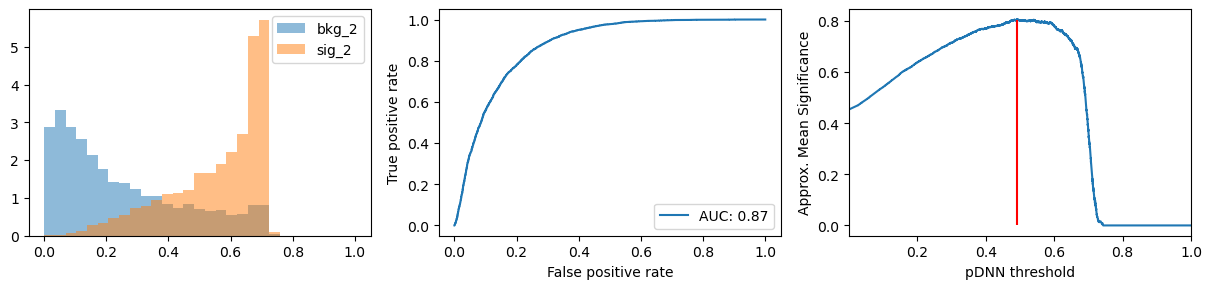

Max AMS sensitivity: 0.81 for thr = 0.4912
bkg rejected: 83.90%
sgn rejected: 28.15%
Final bkg: 173.98
Final sgn: 107397.42
Stats err bkg: 0.026


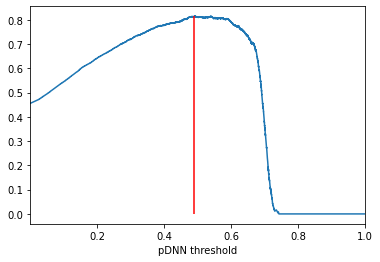

Max sensitivity: 0.81 for thr = 0.4912
bkg rejected: 83.90%
sgn rejected: 28.15%
Final bkg: 173.98
Final sgn: 107397.42
Stats err bkg: 0.026

 Mass point:  4  | iteration n. 1
pre_sel_bkg_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ((massZ2>3.2 & massZ2<3.92) | (massZ2>4.08 & massZ2<4.8)) & pTL4==0
pre_sel_sgn_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ZpMass==4 & massZ2>3.92 & massZ2<4.08 & pTL4==0
bkg evts: 4198 ; in SR 461.78
sig evts: 13986 ; normalized 84915.92


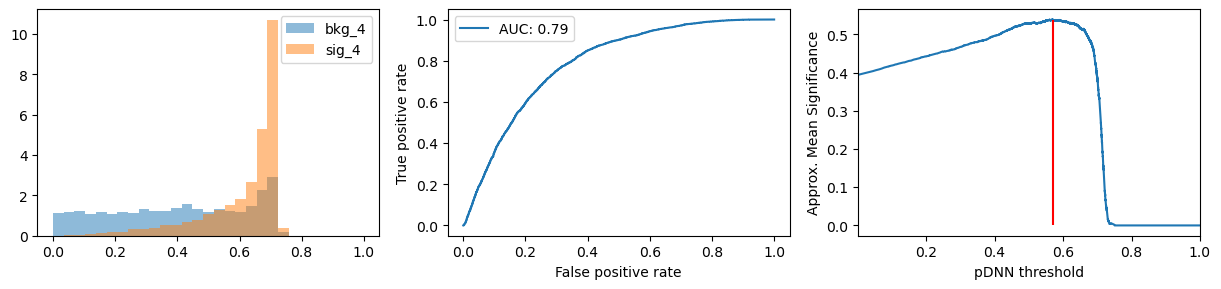

Max AMS sensitivity: 0.54 for thr = 0.5695
bkg rejected: 70.53%
sgn rejected: 25.40%
Final bkg: 136.07
Final sgn: 63349.97
Stats err bkg: 0.028


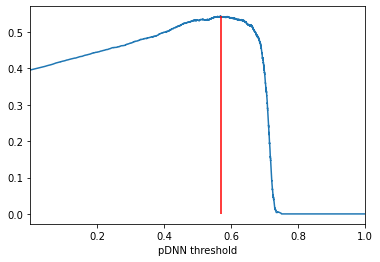

Max sensitivity: 0.54 for thr = 0.5695
bkg rejected: 70.53%
sgn rejected: 25.40%
Final bkg: 136.07
Final sgn: 63349.97
Stats err bkg: 0.028

 Mass point:  5  | iteration n. 2
pre_sel_bkg_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ((massZ2>4.0 & massZ2<4.9) | (massZ2>5.1 & massZ2<6.0)) & pTL4==0
pre_sel_sgn_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ZpMass==5 & massZ2>4.9 & massZ2<5.1 & pTL4==0
bkg evts: 4190 ; in SR 444.14
sig evts: 15376 ; normalized 69062.50


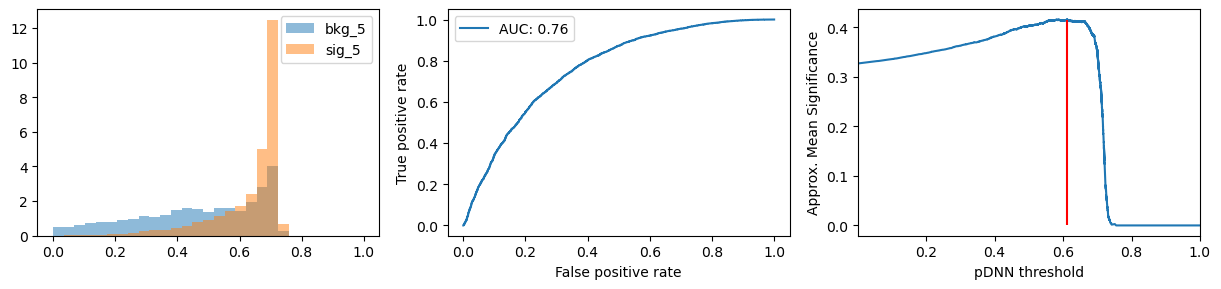

Max AMS sensitivity: 0.42 for thr = 0.6108
bkg rejected: 67.54%
sgn rejected: 27.33%
Final bkg: 144.16
Final sgn: 50188.89
Stats err bkg: 0.027


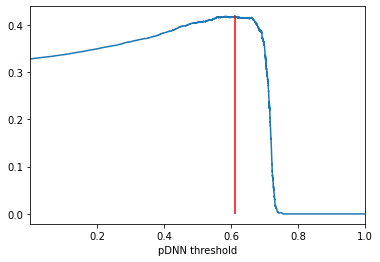

Max sensitivity: 0.42 for thr = 0.6108
bkg rejected: 67.54%
sgn rejected: 27.33%
Final bkg: 144.16
Final sgn: 50188.89
Stats err bkg: 0.027

 Mass point:  15  | iteration n. 3
pre_sel_bkg_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ((massZ2>12.0 & massZ2<14.7) | (massZ2>15.3 & massZ2<18.0)) & pTL4==0
pre_sel_sgn_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ZpMass==15 & massZ2>14.7 & massZ2<15.3 & pTL4==0
bkg evts: 10166 ; in SR 1128.43
sig evts: 36081 ; normalized 33298.92


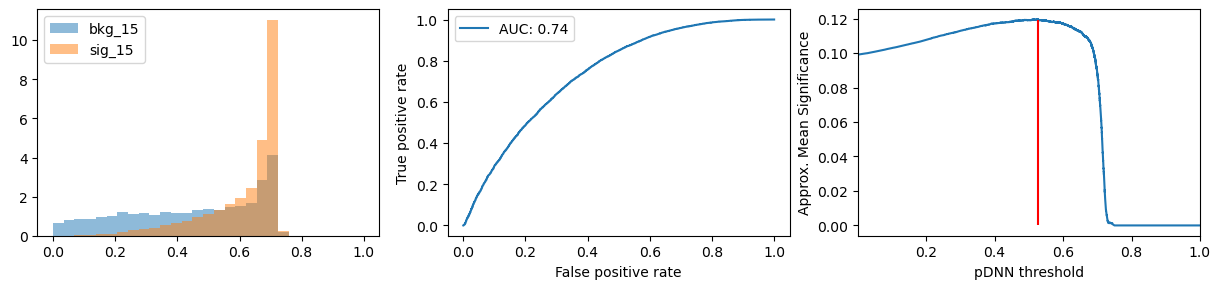

Max AMS sensitivity: 0.12 for thr = 0.5270
bkg rejected: 56.28%
sgn rejected: 20.24%
Final bkg: 493.39
Final sgn: 26558.10
Stats err bkg: 0.015


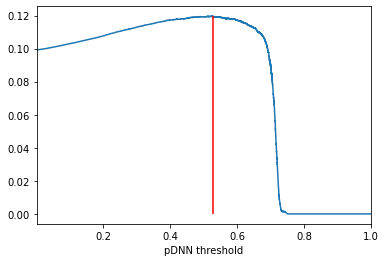

Max sensitivity: 0.12 for thr = 0.5270
bkg rejected: 56.28%
sgn rejected: 20.24%
Final bkg: 493.39
Final sgn: 26558.10
Stats err bkg: 0.015

 Mass point:  20  | iteration n. 4
pre_sel_bkg_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ((massZ2>16.0 & massZ2<19.6) | (massZ2>20.4 & massZ2<24.0)) & pTL4==0
pre_sel_sgn_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ZpMass==20 & massZ2>19.6 & massZ2<20.4 & pTL4==0
bkg evts: 14344 ; in SR 1663.90
sig evts: 50517 ; normalized 25161.21


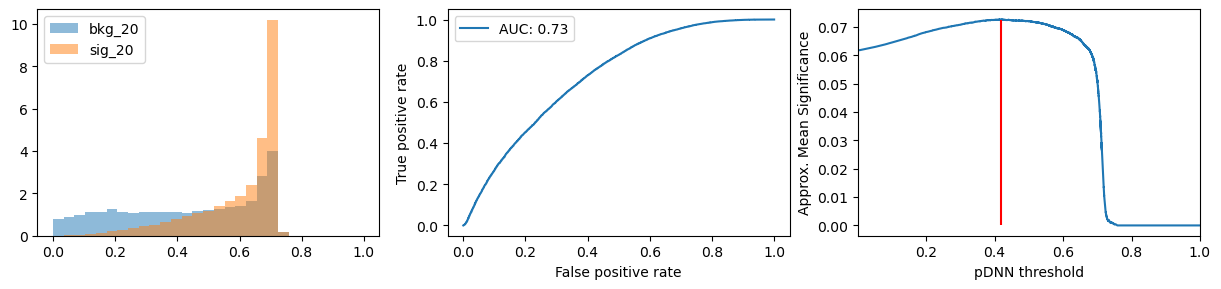

Max AMS sensitivity: 0.07 for thr = 0.4183
bkg rejected: 44.79%
sgn rejected: 12.49%
Final bkg: 918.60
Final sgn: 22017.87
Stats err bkg: 0.011


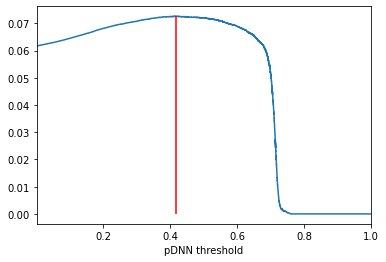

Max sensitivity: 0.07 for thr = 0.4183
bkg rejected: 44.79%
sgn rejected: 12.49%
Final bkg: 918.60
Final sgn: 22017.87
Stats err bkg: 0.011

 Mass point:  25  | iteration n. 5
pre_sel_bkg_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ((massZ2>20.0 & massZ2<24.5) | (massZ2>25.5 & massZ2<30.0)) & pTL4==0
pre_sel_sgn_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ZpMass==25 & massZ2>24.5 & massZ2<25.5 & pTL4==0
bkg evts: 18088 ; in SR 1953.50
sig evts: 52913 ; normalized 14435.07


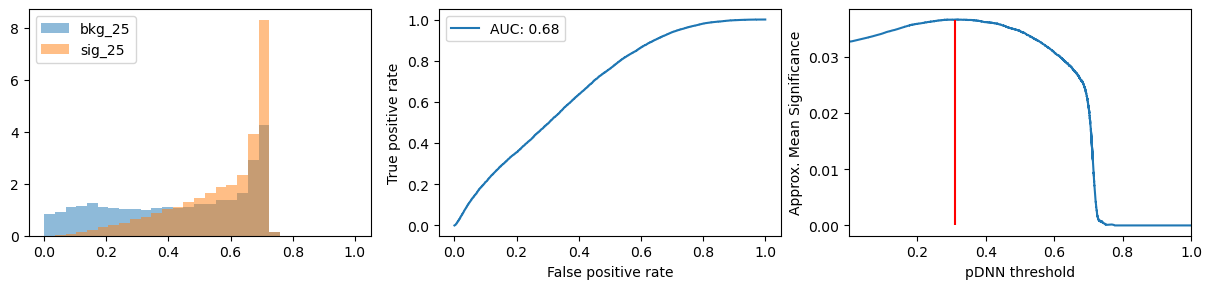

Max AMS sensitivity: 0.04 for thr = 0.3110
bkg rejected: 32.84%
sgn rejected: 8.00%
Final bkg: 1311.88
Final sgn: 13280.00
Stats err bkg: 0.009


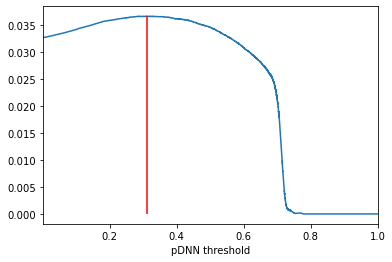

Max sensitivity: 0.04 for thr = 0.3110
bkg rejected: 32.84%
sgn rejected: 8.00%
Final bkg: 1311.88
Final sgn: 13280.00
Stats err bkg: 0.009

 Mass point:  30  | iteration n. 6
pre_sel_bkg_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ((massZ2>24.0 & massZ2<29.4) | (massZ2>30.6 & massZ2<36.0)) & pTL4==0
pre_sel_sgn_eval:  (massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045) & (massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25) & (massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75) & (massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0) & ZpMass==30 & massZ2>29.4 & massZ2<30.6 & pTL4==0
bkg evts: 21255 ; in SR 2295.54
sig evts: 47733 ; normalized 7107.54


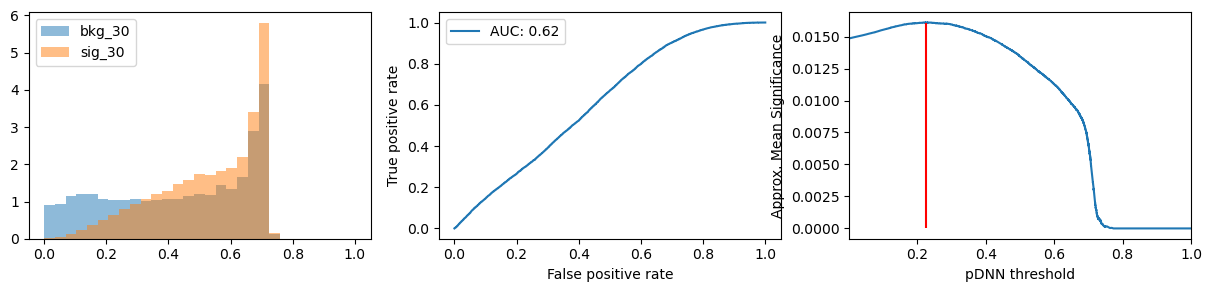

Max AMS sensitivity: 0.02 for thr = 0.2249
bkg rejected: 24.35%
sgn rejected: 5.60%
Final bkg: 1736.64
Final sgn: 6709.23
Stats err bkg: 0.008


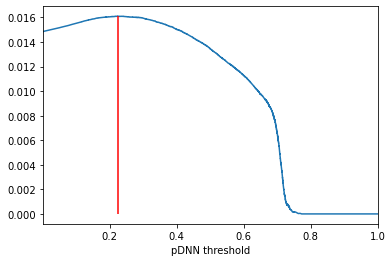

Max sensitivity: 0.02 for thr = 0.2249
bkg rejected: 24.35%
sgn rejected: 5.60%
Final bkg: 1736.64
Final sgn: 6709.23
Stats err bkg: 0.008


In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

#phiVeto = '(massZ1<0.96 | massZ1>1.045) & (massZ2<0.96 | massZ2>1.045)'
#JPsiVeto = '(massZ1<2.9 | massZ1>3.25) & (massZ2<2.9 | massZ2>3.25)'
#PsiPrimeVeto = '(massZ1<3.62 | massZ1>3.75) & (massZ2<3.62 | massZ2>3.75)'
#UpsilonVeto = '(massZ1<9.0 | massZ1>11.0) & (massZ2<9.0 | massZ2>11.0)'
#veto_diMuReso = phiVeto +' & '+ JPsiVeto +' & '+ PsiPrimeVeto +' & '+ UpsilonVeto +' & ' 

# load data (1-25 GeV)
var = ['DNN_score', 'massZ1', 'massZ2', 'ZpMass', 'pTL4']

n_it = 0
#list_LowMass_reduced = [2,5,15,20,25]
bkg_fact = [0.119, 0.11, 0.106, 0.111, 0.116, 0.108, 0.108]
#bkg_fact = [0.12]

for n in list_LowMass_reduced:
    #input_file_sgn_mini = uproot.open("/eos/user/c/caruta/Zp_FinalTrees/Feb18/MiniTree_sgn_pDNN_"+str(n)+".root")
    input_file_sgn_mini = uproot.open("MiniTrees/MiniTree_sgn_pDNN_"+str(n)+".root")
    input_tree_sgn_mini = get_arrays(input_file_sgn_mini['passedEvents'], var)
    #input_file_bkg_mini = uproot.open("/eos/user/c/caruta/Zp_FinalTrees/Feb18/MiniTree_bkg_pDNN_"+str(n)+".root")
    input_file_bkg_mini = uproot.open("MiniTrees/MiniTree_bkg_pDNN_"+str(n)+".root")
    input_tree_bkg_mini = get_arrays(input_file_bkg_mini['passedEvents'], var)

    print("\n Mass point: ", n, " | iteration n.", n_it)
    pre_sel_bkg_eval = veto_diMuReso + '((massZ2>'+str(n-(n*0.2))+' & massZ2<'+str(n-(n*0.02))+') | (massZ2>'+str(n+(n*0.02))+' & massZ2<'+str(n+(n*0.2))+')) & pTL4==0'
    print("pre_sel_bkg_eval: ", pre_sel_bkg_eval)
    preSel_bkg_eval = pre_sel_bkg_eval
    preSel_sgn_eval = veto_diMuReso + 'ZpMass=='+str(n)+' & massZ2>'+str(n-(n*0.02))+' & massZ2<'+str(n+(n*0.02))+' & pTL4==0' 
    print("pre_sel_sgn_eval: ", preSel_sgn_eval)
    
    bkg_X = get_input_features(input_tree_bkg_mini, var, preSel_bkg_eval)
    sig_X = get_input_features(input_tree_sgn_mini, var, preSel_sgn_eval)
    bkg_Y = np.zeros(len(bkg_X))
    sig_Y = np.ones(len(sig_X))
    X = np.concatenate((bkg_X, sig_X))
    Y = np.concatenate((bkg_Y, sig_Y))
    print(f"bkg evts: {len(bkg_X)} ; in SR {len(bkg_X)*bkg_fact[n_it]:.2f}")
    print(f"sig evts: {len(sig_X)} ; normalized {len(sig_X)*norm_fact[n_it]:.2f}")

    plt.figure(figsize=(15, 3), dpi=100)
    plt.subplot(1, 3, 1) 
    plt.hist((bkg_X[:,0]), label='bkg_'+str(n), density=True, alpha=0.5, bins=np.linspace(0, 1, 30))
    plt.hist((sig_X[:,0]), label='sig_'+str(n), density=True, alpha=0.5, bins=np.linspace(0, 1, 30))
    plt.legend()
    #plt.show()

    auc = roc_auc_score(Y, X[:,0])
    fpr, tpr, thr = roc_curve(Y, X[:,0], drop_intermediate=True)

    plt.subplot(1, 3, 2) 
    plt.plot(fpr, tpr, label=f"AUC: {auc:.2f}")
    plt.ylabel("True positive rate")
    plt.xlabel("False positive rate")
    plt.legend()
    #plt.show()

    
    ### Std significance: S/sqrt(B) & AMS significance (signal normalized to 10^-4)
    sgn = np.array(tpr)*norm_fact[n_it]*len(sig_X)*0.0001
    bkg = np.array(fpr)*bkg_fact[n_it]*len(bkg_X)
    sensitivity = np.zeros(len(fpr))
    AMS_sens = np.zeros(len(fpr))
        
    for i in range(len(fpr)):
        if ((fpr[i] != 0) & (tpr[i] != 0)):
            sensitivity[i] = np.array(sgn[i]/(np.sqrt(bkg[i])))
            AMS_sens[i] = np.sqrt( 2.* ( (sgn[i]+bkg[i]) * np.log(1+(sgn[i]/bkg[i])) - sgn[i] ) )
        else:
            sensitivity[i] = 0
            AMS_sens[i] = 0
            
    plt.subplot(1, 3, 3)  
    plt.plot(thr, AMS_sens)
    plt.vlines(x=thr[AMS_sens.argmax()], ymin=min(AMS_sens), ymax=max(AMS_sens), color='red')
    plt.xlim(0.001, 1.0)
    plt.xlabel("pDNN threshold")
    plt.ylabel("Approx. Mean Significance")
    plt.show()
                  
    print(f"Max AMS sensitivity: {max(AMS_sens):.2f} for thr = {thr[AMS_sens.argmax()]:.4f}")
    bkg_rej_AMS = 1. - fpr[AMS_sens.argmax()]
    sgn_rej_AMS = 1. - tpr[AMS_sens.argmax()]
    print(f"bkg rejected: {bkg_rej_AMS*100:.2f}%")
    print(f"sgn rejected: {sgn_rej_AMS*100:.2f}%")
    print(f"Final bkg: {(1-bkg_rej_AMS)*len(bkg_X)*bkg_fact[n_it]:.2f}")
    print(f"Final sgn: {(1-sgn_rej_AMS)*len(sig_X)*norm_fact[n_it]:.2f}")
    print(f"Stats err bkg: {(1/np.sqrt((1-bkg_rej_AMS)*len(bkg_X))):.3f}")
    stats_err_AMS = 1.+(1/np.sqrt((1-bkg_rej_AMS)*len(bkg_X)))
    
    #plt.subplot(1, 4, 4) 
    plt.plot(thr, sensitivity)
    plt.vlines(x=thr[sensitivity.argmax()], ymin=min(sensitivity), ymax=max(sensitivity), color='red')
    plt.xlim(0.001, 1.0)
    plt.xlabel("pDNN threshold")
    plt.show()
    print(f"Max sensitivity: {max(sensitivity):.2f} for thr = {thr[sensitivity.argmax()]:.4f}")
    bkg_rej = 1. - fpr[sensitivity.argmax()]
    sgn_rej = 1. - tpr[sensitivity.argmax()]

    print(f"bkg rejected: {bkg_rej*100:.2f}%")
    print(f"sgn rejected: {sgn_rej*100:.2f}%")
    print(f"Final bkg: {(1-bkg_rej)*len(bkg_X)*bkg_fact[n_it]:.2f}")
    print(f"Final sgn: {(1-sgn_rej)*len(sig_X)*norm_fact[n_it]:.2f}")
    print(f"Stats err bkg: {(1/np.sqrt((1-bkg_rej)*len(bkg_X))):.3f}")
    stats_err = 1.+(1/np.sqrt((1-bkg_rej)*len(bkg_X)))
    
    ### Write datacards (signal normalized to 10^-4)
    f = open("/eos/user/c/caruta/Wto3l_Combine/Combine_v8/CMSSW_10_2_13/src/HiggsAnalysis/CombinedLimit/NewDatacards/datacard_Zp"+str(n)+".txt", "w")
    f.write("imax 1  number of channels\njmax 1  number of backgrounds")
    f.write("\nkmax *  number of nuisance parameters (sources of systematical uncertainties)")
    f.write("\n------------\nbin bin1")
    f.write(f"\nobservation {(1-bkg_rej_AMS)*len(bkg_X)*bkg_fact[n_it]:.2f}")
    f.write("\n------------\nbin             bin1 bin1")
    f.write("\nprocess         Zp  dataSB\nprocess          0    1")
    f.write(f"\nrate         {(1-sgn_rej_AMS)*len(sig_X)*norm_fact[n_it]*0.0001:.2f}"+f" {(1-bkg_rej_AMS)*len(bkg_X)*bkg_fact[n_it]:.2f}")
    f.close()
    
    f = open("/eos/user/c/caruta/Wto3l_Combine/Combine_v8/CMSSW_10_2_13/src/HiggsAnalysis/CombinedLimit/NewDatacards/datacard_Zp"+str(n)+".txt", "a")
    f.write("\n------------")
    f.write(f"\nstats  lnN    -    {stats_err_AMS:.3f}")
    f.close()
    
    n_it+=1